# 🏥 Healthcare Management Analytics using Python

## Project Overview

This project performs exploratory data analysis (EDA) on hospital management data using Python. The analysis focuses on patient demographics, doctor performance, appointments, billing, and pharmacy inventory to generate business insights.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
patients = pd.read_csv("Patients.csv")
doctors = pd.read_csv("Doctors.csv")
departments = pd.read_csv("Departments.csv")
appointments = pd.read_csv("Appointments.csv")
billing = pd.read_csv("Billing.csv")
pharmacy = pd.read_csv("Pharmacy.csv")

In [ ]:
patients.head()

,Patient_ID,Patient_Name,Age,Gender,City,Admission_Date,Discharge_Date,Department_ID,Doctor_ID,Diagnosis_Code,Treatment_Cost,Insurance_Type,Readmitted
0,P00001,Patient1,80,Female,Bengaluru,2026-04-17,2026-04-23,D001,DR001,DX837,44363,Self,No
1,P00002,Patient2,42,Female,Hassan,2025-12-08,2025-12-15,D002,DR002,DX667,21683,Private,No
2,P00003,Patient3,87,Male,Hubballi,2025-12-07,2025-12-14,D003,DR003,DX682,44446,Government,Yes
3,P00004,Patient4,27,Female,Hubballi,2025-06-05,2025-06-10,D004,DR004,DX721,47237,Government,No
4,P00005,Patient5,66,Female,Mysuru,2025-08-15,2025-08-19,D005,DR005,DX774,16114,Government,No


In [ ]:
doctors.head()

,Doctor_ID,Doctor_Name,Gender,Department_ID,Department_Name,Specialization,Experience_Years,Qualification,Consultation_Fee,Email,Phone
0,DR001,Dr1,Male,D001,Cardiology,Cardiologist,2,MBBS DM,1063,dr001@medicare.com,9362950628
1,DR002,Dr2,Male,D002,Neurology,Neurologist,6,MBBS DM,709,dr002@medicare.com,9826600539
2,DR003,Dr3,Male,D003,Orthopedics,Orthopedic Surgeon,20,MBBS MS,565,dr003@medicare.com,9131994523
3,DR004,Dr4,Male,D004,Pediatrics,Pediatrician,8,MBBS MD,1534,dr004@medicare.com,9746412689
4,DR005,Dr5,Male,D005,Oncology,Oncologist,19,MBBS MD,1966,dr005@medicare.com,9797808098


In [ ]:
billing.head()

,Bill_ID,Patient_ID,Treatment_Cost,Medicine_Cost,Lab_Cost,Insurance_Coverage,Net_Bill,Payment_Method,Payment_Status
0,B00001,P00001,44363,858,841,8137,37925,Cash,Pending
1,B00002,P00002,21683,1668,2869,9824,16396,Cash,Paid
2,B00003,P00003,44446,1371,2521,11088,37250,UPI,Paid
3,B00004,P00004,47237,2157,870,15742,34522,UPI,Pending
4,B00005,P00005,16114,1836,1559,2717,16792,Card,Paid


In [ ]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      1000 non-null   object
 1   Patient_Name    1000 non-null   object
 2   Age             1000 non-null   int64 
 3   Gender          1000 non-null   object
 4   City            1000 non-null   object
 5   Admission_Date  1000 non-null   object
 6   Discharge_Date  1000 non-null   object
 7   Department_ID   1000 non-null   object
 8   Doctor_ID       1000 non-null   object
 9   Diagnosis_Code  1000 non-null   object
 10  Treatment_Cost  1000 non-null   int64 
 11  Insurance_Type  1000 non-null   object
 12  Readmitted      1000 non-null   object
dtypes: int64(2), object(11)
memory usage: 101.7+ KB


In [ ]:
doctors.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Doctor_ID         100 non-null    object
 1   Doctor_Name       100 non-null    object
 2   Gender            100 non-null    object
 3   Department_ID     100 non-null    object
 4   Department_Name   100 non-null    object
 5   Specialization    100 non-null    object
 6   Experience_Years  100 non-null    int64 
 7   Qualification     100 non-null    object
 8   Consultation_Fee  100 non-null    int64 
 9   Email             100 non-null    object
 10  Phone             100 non-null    int64 
dtypes: int64(3), object(8)
memory usage: 8.7+ KB


In [ ]:
billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Bill_ID             1000 non-null   object
 1   Patient_ID          1000 non-null   object
 2   Treatment_Cost      1000 non-null   int64 
 3   Medicine_Cost       1000 non-null   int64 
 4   Lab_Cost            1000 non-null   int64 
 5   Insurance_Coverage  1000 non-null   int64 
 6   Net_Bill            1000 non-null   int64 
 7   Payment_Method      1000 non-null   object
 8   Payment_Status      1000 non-null   object
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
patients.isnull().sum()

,0
Patient_ID,0
Patient_Name,0
Age,0
Gender,0
City,0
Admission_Date,0
Discharge_Date,0
Department_ID,0
Doctor_ID,0
Diagnosis_Code,0


In [ ]:
doctors.isnull().sum()

,0
Doctor_ID,0
Doctor_Name,0
Gender,0
Department_ID,0
Department_Name,0
Specialization,0
Experience_Years,0
Qualification,0
Consultation_Fee,0
Email,0


In [ ]:
billing.isnull().sum()

,0
Bill_ID,0
Patient_ID,0
Treatment_Cost,0
Medicine_Cost,0
Lab_Cost,0
Insurance_Coverage,0
Net_Bill,0
Payment_Method,0
Payment_Status,0


In [ ]:
patients.duplicated().sum()

np.int64(0)

In [ ]:
doctors.duplicated().sum()

np.int64(0)

In [ ]:
billing.duplicated().sum()

np.int64(0)

In [ ]:
patients.describe()

,Age,Treatment_Cost
count,1000.000000,1000.000000
mean,45.902000,43903.748000
std,25.626492,21608.782841
min,1.000000,5089.000000
25%,24.000000,24174.500000
50%,46.000000,45606.500000
75%,68.000000,62644.500000
max,90.000000,79967.000000


In [ ]:
billing.describe()

,Treatment_Cost,Medicine_Cost,Lab_Cost,Insurance_Coverage,Net_Bill
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43903.748000,2806.604000,1624.349000,11070.615000,37264.086000
std,21608.782841,1277.603398,765.235117,8948.380268,17825.098559
min,5089.000000,500.000000,302.000000,16.000000,4942.000000
25%,24174.500000,1709.000000,961.000000,3683.750000,22066.250000
50%,45606.500000,2819.500000,1613.000000,8635.500000,36493.000000
75%,62644.500000,3911.750000,2268.250000,16300.500000,50068.000000
max,79967.000000,5000.000000,3000.000000,38046.000000,84244.000000


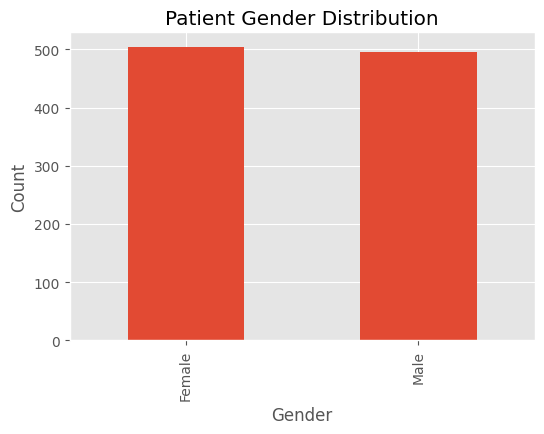

In [ ]:
plt.figure(figsize=(6,4))

patients["Gender"].value_counts().plot(kind="bar")

plt.title("Patient Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

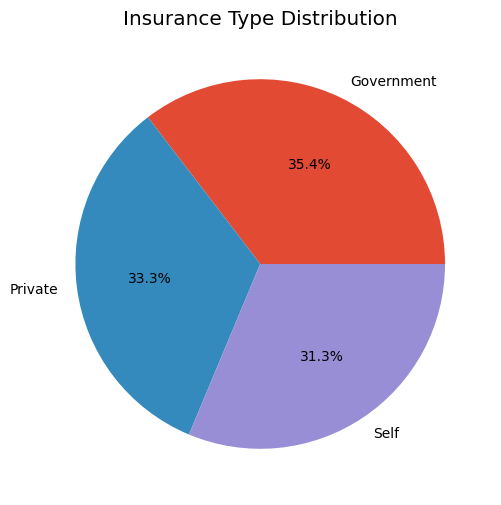

In [ ]:
plt.figure(figsize=(6,6))

patients["Insurance_Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Insurance Type Distribution")

plt.show()

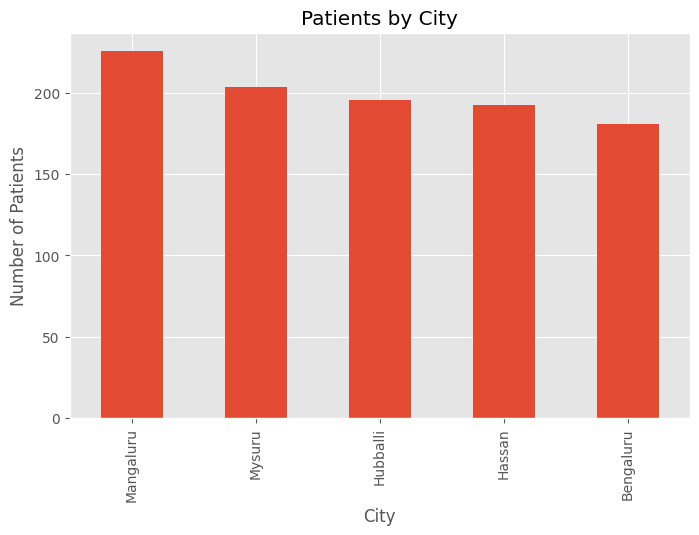

In [ ]:
plt.figure(figsize=(8,5))

patients["City"].value_counts().plot(kind="bar")

plt.title("Patients by City")
plt.xlabel("City")
plt.ylabel("Number of Patients")

plt.show()

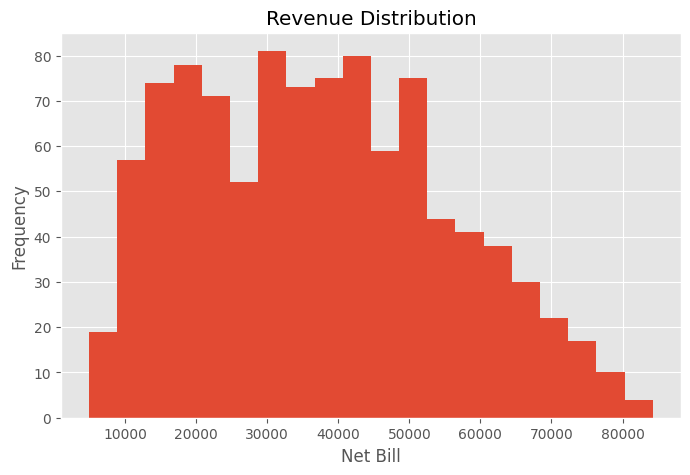

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(billing["Net_Bill"], bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Net Bill")
plt.ylabel("Frequency")

plt.show()

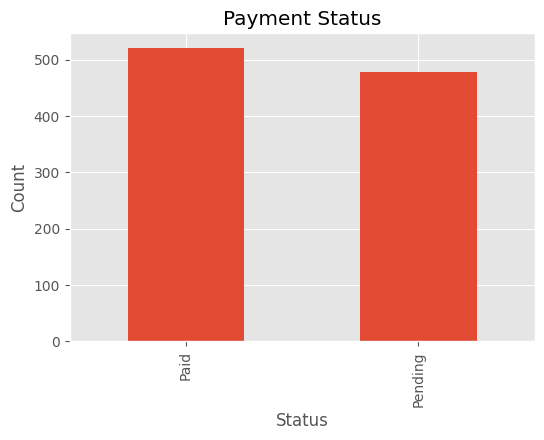

In [ ]:
plt.figure(figsize=(6,4))

billing["Payment_Status"].value_counts().plot(kind="bar")

plt.title("Payment Status")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

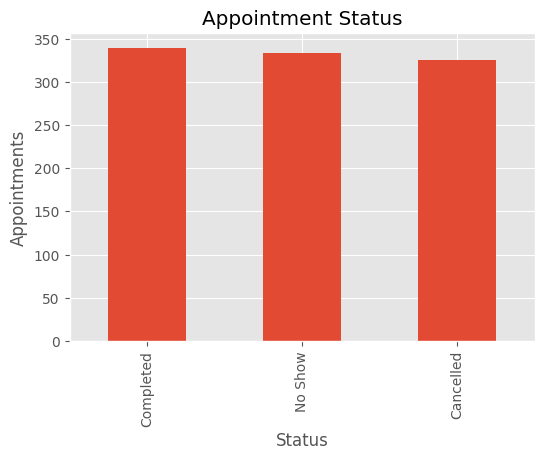

In [ ]:
plt.figure(figsize=(6,4))

appointments["Appointment_Status"].value_counts().plot(kind="bar")

plt.title("Appointment Status")
plt.xlabel("Status")
plt.ylabel("Appointments")

plt.show()

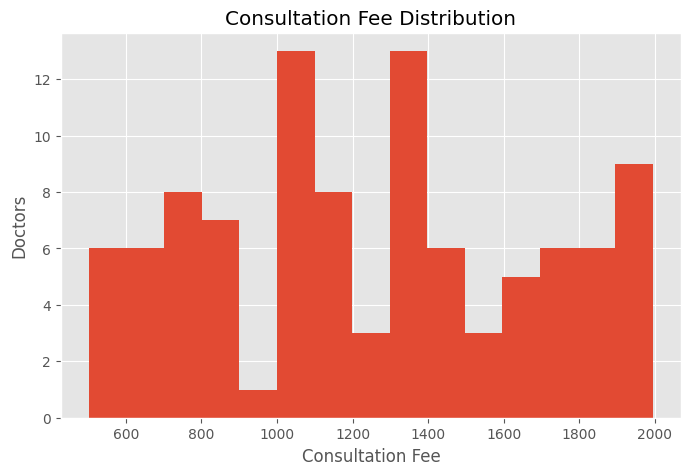

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(doctors["Consultation_Fee"], bins=15)

plt.title("Consultation Fee Distribution")
plt.xlabel("Consultation Fee")
plt.ylabel("Doctors")

plt.show()

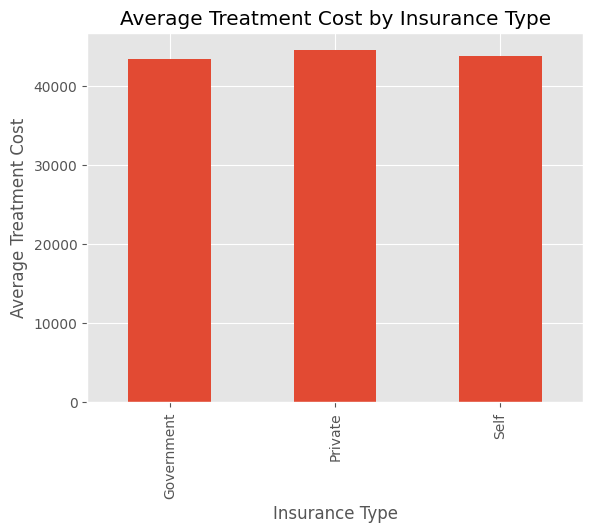

In [ ]:
patients.groupby("Insurance_Type")["Treatment_Cost"].mean().plot(kind="bar")

plt.title("Average Treatment Cost by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Average Treatment Cost")

plt.show()

## Business Insights

- The hospital treated 1,000 patients.
- Patient distribution varies across cities, indicating regional demand differences.
- Revenue is generated from multiple departments and billing activities.
- Payment status analysis helps identify outstanding collections.
- Insurance coverage varies across patients.
- Appointment analysis highlights completed, cancelled, and no-show visits.
- Consultation fees differ among doctors, reflecting specialization and experience.
- Readmission data can help monitor quality of patient care.


## Conclusion

Python-based exploratory data analysis provided valuable insights into hospital operations, patient demographics, billing, appointments, and doctor performance. The findings complement the SQL analysis and Power BI dashboard, providing a comprehensive view of healthcare management data for informed business decision-making.